# MDR-TS v20.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v20.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Combating variance and heteroscedasticity.

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

import torch

import statsmodels.api as sm
import statsmodels.stats.api as sms

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v20"
SUBVERSION = "v20.2"
RUN_NAME = "mdr_ts_v20_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v20/v20.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [6]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
    ]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 38
  Target:   soil_moisture_5cm


In [8]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics):
    print(f"{'METRIC':<15} | {'VALUE':<10}")
    print("-" * 28)
    for k, v in metrics.items():
        val_str = f"{v:,}" if isinstance(v, int) else f"{v:+.5f}"
        print(f"{k:<15} | {val_str:<10}")

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [11]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df[FEATURE_COLS].copy()
y_test_d = test_df[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (9588, 38)
  X_test_d:     (4016, 38)


### Base Model

In [12]:
XGB_PARAMS = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [15]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_tv = XGBRegressor(**XGB_PARAMS)
xgb_drift_tv.fit(
  trainval_df_d[FEATURE_COLS],
  trainval_df_d[TARGET_COL],
  verbose=0,
  )

y_test_d = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test = np.asarray(xgb_drift_tv.predict(test_df[FEATURE_COLS])).ravel()

In [16]:
metrics_dashboard(y_test_d, pred_drift_test, name="Test No Weights", return_dict=False)

In [17]:
print("===== NON-WEIGHTED MODEL METRICS =====")
neat_print(get_metrics_dict(y_test_d, pred_drift_test, prefix="no_w_"))

===== NON-WEIGHTED MODEL METRICS =====
METRIC          | VALUE     
----------------------------
no_w_n          | 4,016     
no_w_r2         | +0.81418  
no_w_mae        | +0.03039  
no_w_rmse       | +0.04059  
no_w_ubrmse     | +0.04049  
no_w_bias       | -0.00284  
no_w_med_ae     | +0.02369  
no_w_p90_ae     | +0.06337  
no_w_q05_err    | -0.07006  
no_w_q50_err    | -0.00325  
no_w_q95_err    | +0.05743  


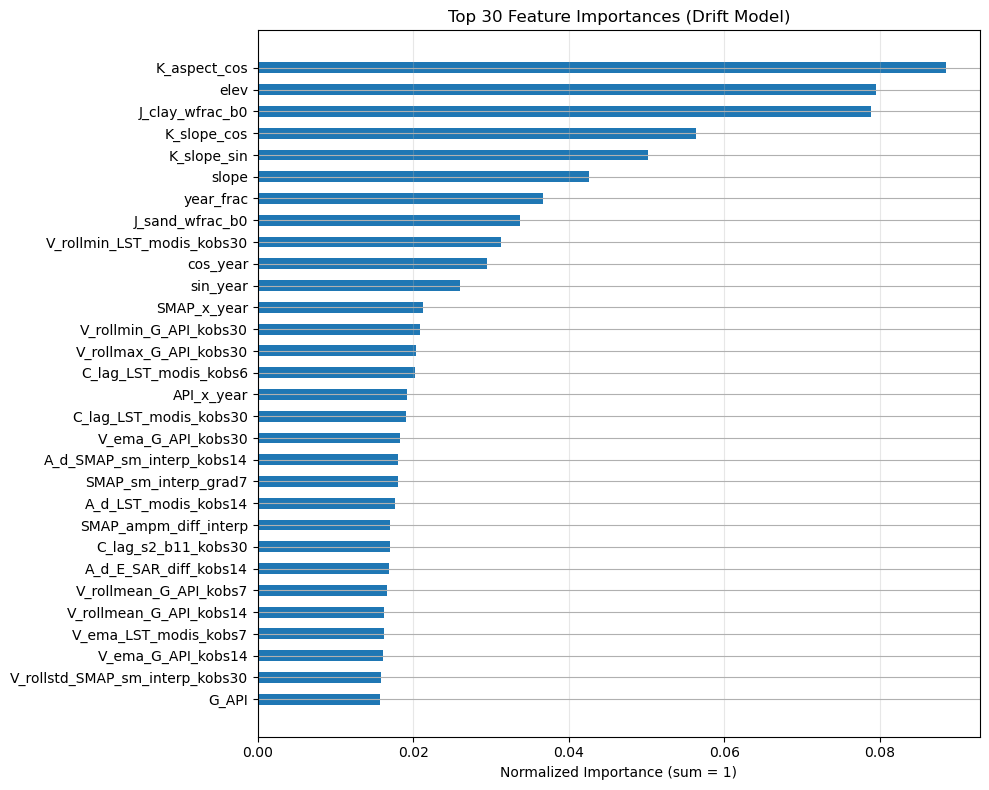

In [18]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

imp = get_xgb_importance(xgb_drift_tv, FEATURE_COLS)

TOP_K = 30
imp_top = imp.sort_values(ascending=False).head(TOP_K)
imp_top_sorted = imp_top.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
y = np.arange(len(imp_top_sorted))

plt.barh(y, imp_top_sorted.values, height=0.5)

plt.yticks(y, imp_top_sorted.index)
plt.xlabel("Normalized Importance (sum = 1)")
plt.title(f"Top {TOP_K} Feature Importances (Drift Model)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
display(imp)

SMAP_sm_pm_interp_ema02            0.010947
V_rollmin_LST_modis_kobs30         0.031330
D_sin_DOY                          0.011200
G_rain_sum_3d                      0.013107
V_ema_G_API_kobs7                  0.012562
V_rollmin_G_API_kobs30             0.020867
G_rain_sum_7d                      0.014036
C_lag_LST_modis_kobs30             0.019112
C_lag_G_API_kobs1                  0.015020
V_ema_G_API_kobs14                 0.016047
V_rollmean_G_API_kobs14            0.016180
G_API                              0.015695
G_DSLR                             0.014246
SMAP_ampm_diff_interp              0.017016
V_rollmax_G_API_kobs30             0.020336
V_ema_G_API_kobs30                 0.018276
V_rollmean_s2_b11_kobs7            0.015460
V_ema_LST_modis_kobs7              0.016178
V_rollmean_G_API_kobs7             0.016632
C_lag_s2_b11_kobs30                0.016970
A_d_E_SAR_diff_kobs14              0.016871
C_lag_LST_modis_kobs6              0.020197
A_d_LST_modis_kobs14            

### Residuals

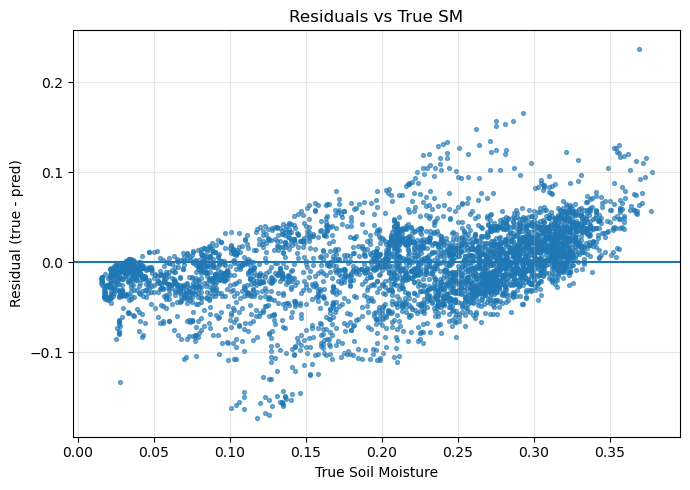

In [23]:
y_true = np.asarray(y_test_d).ravel()
y_pred = np.asarray(pred_drift_test).ravel()

res_nw = y_true - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_true, res_nw, s=8, alpha=0.6)
plt.axhline(0)

plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True SM")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

### Regimes

In [32]:
t1 = 0.20
t2 = 0.313

y_tv = np.asarray(y_trainval_d).ravel()

reg_tv = np.zeros_like(y_tv, dtype=int)
reg_tv[(y_tv > t1) & (y_tv <= t2)] = 1
reg_tv[y_tv > t2] = 2

unique, counts = np.unique(reg_tv, return_counts=True)
print("Trainval regime counts:", dict(zip(unique, counts)))

Trainval regime counts: {0: 4280, 1: 3885, 2: 1423}


In [33]:
from xgboost import XGBRegressor
import numpy as np

models_reg = {}

for r in [0, 1, 2]:
    mask = reg_tv == r
    print(f"Training regime {r}: n={mask.sum()}")

    m = XGBRegressor(**XGB_PARAMS)
    m.fit(
        X_trainval_d[mask],
        np.asarray(y_trainval_d).ravel()[mask],
        verbose=0
    )
    models_reg[r] = m

Training regime 0: n=4280
Training regime 1: n=3885
Training regime 2: n=1423


In [34]:
y_true_test = np.asarray(y_test_d).ravel()
y_pred_base = np.asarray(pred_drift_test).ravel()

print("Shapes:", y_true_test.shape, y_pred_base.shape)

Shapes: (4016,) (4016,)


In [35]:
reg_test = np.zeros_like(y_pred_base, dtype=int)
reg_test[(y_pred_base > t1) & (y_pred_base <= t2)] = 1
reg_test[y_pred_base > t2] = 2

pred_hard = np.zeros_like(y_pred_base, dtype=float)

for r in [0, 1, 2]:
    mask = reg_test == r
    if mask.sum() > 0:
        pred_hard[mask] = np.asarray(models_reg[r].predict(X_test_d[mask])).ravel()

print("Test regime counts:", dict(zip(*np.unique(reg_test, return_counts=True))))

Test regime counts: {0: 1515, 1: 2259, 2: 242}


In [36]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def soft_gate_weights(y_gate, t1, t2, width1=0.015, width2=0.015):
    y = np.asarray(y_gate).ravel()

    s1 = sigmoid((y - t1) / width1)  # 0->1 around t1
    s2 = sigmoid((y - t2) / width2)  # 0->1 around t2

    w0 = 1.0 - s1
    w2 = s2
    w1 = s1 - s2

    w0 = np.clip(w0, 0.0, 1.0)
    w1 = np.clip(w1, 0.0, 1.0)
    w2 = np.clip(w2, 0.0, 1.0)

    W = w0 + w1 + w2
    w0, w1, w2 = w0 / W, w1 / W, w2 / W

    return w0, w1, w2

In [37]:
pred0 = np.asarray(models_reg[0].predict(X_test_d)).ravel()
pred1 = np.asarray(models_reg[1].predict(X_test_d)).ravel()
pred2 = np.asarray(models_reg[2].predict(X_test_d)).ravel()

print(pred0.shape, pred1.shape, pred2.shape)

(4016,) (4016,) (4016,)


In [50]:
width1 = 0.04
width2 = 0.04

w0, w1, w2 = soft_gate_weights(y_pred_base, t1=t1, t2=t2, width1=width1, width2=width2)

pred_soft = w0 * pred0 + w1 * pred1 + w2 * pred2

print("Weights:")
print("  w0 min/max:", w0.min(), w0.max())
print("  w1 min/max:", w1.min(), w1.max())
print("  w2 min/max:", w2.min(), w2.max())
print("  sum min/max:", (w0+w1+w2).min(), (w0+w1+w2).max())

Weights:
  w0 min/max: 0.023318708 0.98708344
  w1 min/max: 0.012141088 0.6083198
  w2 min/max: 0.00077548786 0.71298075
  sum min/max: 0.9999999 1.0000001


In [51]:
print("=== BASE ===")
print("R2  :", r2_score(y_true_test, y_pred_base))
print("MAE :", mean_absolute_error(y_true_test, y_pred_base))
print("RMSE:", rmse(y_true_test, y_pred_base))

print("\n=== HARD GATE ===")
print("R2  :", r2_score(y_true_test, pred_hard))
print("MAE :", mean_absolute_error(y_true_test, pred_hard))
print("RMSE:", rmse(y_true_test, pred_hard))

print("\n=== SOFT GATE ===")
print("R2  :", r2_score(y_true_test, pred_soft))
print("MAE :", mean_absolute_error(y_true_test, pred_soft))
print("RMSE:", rmse(y_true_test, pred_soft))

=== BASE ===
R2  : 0.8141840910766629
MAE : 0.03039237889640805
RMSE: 0.04059057022121844

=== HARD GATE ===
R2  : 0.7916630437241189
MAE : 0.03133323744359051
RMSE: 0.042980044701878314

=== SOFT GATE ===
R2  : 0.8224205273256091
MAE : 0.029431325363600064
RMSE: 0.039680769576605136


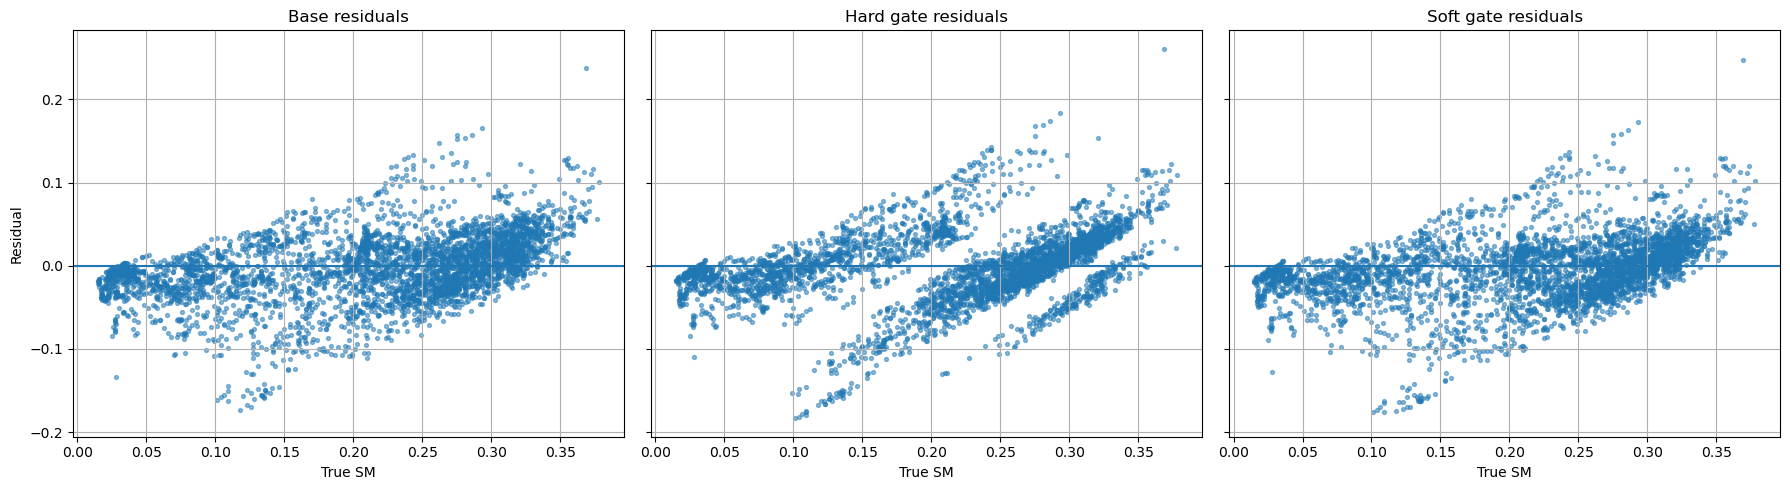

In [45]:
res_base = y_true_test - y_pred_base
res_hard = y_true_test - pred_hard
res_soft = y_true_test - pred_soft

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_true_test, res_base, s=8, alpha=0.5)
axes[0].axhline(0)
axes[0].set_title("Base residuals")
axes[0].set_xlabel("True SM")
axes[0].set_ylabel("Residual")

axes[1].scatter(y_true_test, res_hard, s=8, alpha=0.5)
axes[1].axhline(0)
axes[1].set_title("Hard gate residuals")
axes[1].set_xlabel("True SM")

axes[2].scatter(y_true_test, res_soft, s=8, alpha=0.5)
axes[2].axhline(0)
axes[2].set_title("Soft gate residuals")
axes[2].set_xlabel("True SM")

plt.tight_layout()
plt.show()

In [49]:
width_grid = [0.03, 0.04, 0.041, 0.042, 0.045]

rows = []
for w in width_grid:
    w0, w1, w2 = soft_gate_weights(y_pred_base, t1=t1, t2=t2, width1=w, width2=w)
    pred_soft_w = w0 * pred0 + w1 * pred1 + w2 * pred2
    rows.append((w, r2_score(y_true_test, pred_soft_w), rmse(y_true_test, pred_soft_w)))

rows = sorted(rows, key=lambda x: x[2])  # sort by RMSE

print("width | R2 | RMSE (sorted by RMSE)")
for w, r2, r in rows:
    print(f"{w:0.3f} | {r2:0.6f} | {r:0.6f}")

width | R2 | RMSE (sorted by RMSE)
0.040 | 0.822421 | 0.039681
0.041 | 0.822395 | 0.039684
0.042 | 0.822321 | 0.039692
0.045 | 0.821811 | 0.039749
0.030 | 0.820299 | 0.039917


---

_Jakob Balkovec_